<a href="https://colab.research.google.com/github/jongwoo108/APTOS-Diabetic-Retinopathy-Classification/blob/main/APTOS_2019_Blindness_Detection_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# APTOS 2019 v2 — 변경 사항 정리

## v1 문제점 요약
- `self.model.classfier` 오타로 1000개 출력층에서 앞 5개를 슬라이싱하는 비정상 구조
- 정규화 누락 (0~255 raw 입력으로 학습)
- Augmentation 없음, 스케줄러 없음
- 데이터 불균형 미처리 (class 0: 1805개 vs class 3: 193개)
- 결과: Public Kappa 0.80

---

## v2 변경 내용

### 1. 데이터 불균형 해소 (최우선)
| 항목 | v1 | v2 |
|------|----|----|
| 샘플링 | shuffle=True (다수 클래스 편향) | WeightedRandomSampler (균등 샘플링) |
| Loss 가중치 | 없음 | 클래스별 역빈도 가중치 적용 |

### 2. 손실 함수 변경
| 항목 | v1 | v2 |
|------|----|----|
| Loss | CrossEntropyLoss | CORAL Ordinal Regression |
| 출력 | 1000개 중 [:5] 슬라이싱 | 4개 이진 출력 (순서형) |
| 순서 인식 | 없음 (0→4 오분류 = 0→1 오분류) | 있음 (인접 클래스 혼동 최소화) |

### 3. Augmentation + 전처리 + 스케줄러
| 항목 | v1 | v2 |
|------|----|----|
| 정규화 | 없음 (0~255) | /255 + ImageNet normalize |
| Augmentation | 없음 | Flip, Rotate, ShiftScale, Noise, Distortion, CoarseDropout |
| Optimizer | Adam, lr=1e-4 고정 | AdamW + weight decay |
| Scheduler | 없음 | CosineAnnealingLR (1e-4 → 1e-6) |
| Epochs | 10 | 25 |

### 4. 모델 업그레이드
| 항목 | v1 | v2 |
|------|----|----|
| 모델 | EfficientNet-B0 (5.3M params) | EfficientNet-B3 (12M params) |
| 입력 크기 | 224×224 | 300×300 |
| Head | classfier 오타 + 1000→5 슬라이싱 | Dropout(0.3) + Linear(1536→4) |

### 5. 안정성
- 매 epoch 구글 드라이브에 체크포인트 저장
- 런타임 끊김 시 자동 이어하기 (resume)
- Gradient clipping (max_norm=1.0)

---

## 기대 효과
- v1 Public Kappa: **0.80** → v2 목표: **0.85+**
- CORAL Loss가 QWK 지표와 직접 연결되어 먼 클래스 오분류 감소
- 소수 클래스(1, 3, 4) 재현율 개선

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"jongwoo108","key":"1cbf546b90347698721b3936ecfc7648"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('/content/kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

In [ ]:
!kaggle competitions download -c aptos2019-blindness-detection
!mkdir -p /content/aptos_data
!unzip -q aptos2019-blindness-detection.zip -d /content/aptos_data

100% 9.51G/9.51G [00:56<00:00, 182MB/s]



In [ ]:
import os
print(os.listdir('/content/aptos_data'))

['train_images', 'test_images', 'train.csv', 'test.csv', 'sample_submission.csv']


In [ ]:
# ============================================================
# 0. 설치 (Colab 첫 셀에서 실행)
# ============================================================
# !pip install timm albumentations scikit-learn

import os
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import cohen_kappa_score
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# ============================================================
# 1. 설정
# ============================================================
class CFG:
    # ── 데이터 ──
    data_dir = '/content/aptos_data'
    train_csv = '/content/aptos_data/train.csv'
    train_img_dir = '/content/aptos_data/train_images'

    # ── 모델 ──
    model_name = 'efficientnet_b3'  # B0(224) → B3(300) 업그레이드
    img_size = 300                   # B3 권장 입력 크기
    num_classes = 5
    pretrained = True

    # ── 학습 ──
    epochs = 25
    batch_size = 16          # T4 15GB에서 B3 + 300x300 → 16이 안정
    lr = 1e-4
    weight_decay = 1e-5
    num_workers = 2
    seed = 42
    n_folds = 5
    train_folds = [0]        # 빠른 실험: 1 fold만. 전체: [0,1,2,3,4]

    # ── 체크포인트 (추가) ──
    checkpoint_dir = '/content/drive/MyDrive/aptos_checkpoints'
    resume = True

    # ── 전처리 ──
    ben_sigma = 10
    # ImageNet 정규화 (pretrained 모델 필수)
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def seed_everything(seed):
    import random
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(CFG.seed)

In [ ]:
# ============================================================
# 2. 전처리 함수
# ============================================================

def crop_image_from_gray(img, tol=7):
    if img.ndim == 2:
        mask = img > tol
        return img[np.ix_(mask.any(1), mask.any(0))]
    elif img.ndim == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        mask = gray > tol
        if not np.any(mask):
            return img
        return img[np.ix_(np.any(mask, axis=1), np.any(mask, axis=0))]
    return img


def load_ben_color(path, img_size=300, sigmaX=10):
    """Ben Graham 전처리 + crop + resize"""
    image = cv2.imread(path)
    if image is None:
        return np.zeros((img_size, img_size, 3), dtype=np.uint8)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = crop_image_from_gray(image)
    image = cv2.resize(image, (img_size, img_size))
    image = cv2.addWeighted(image, 4, cv2.GaussianBlur(image, (0, 0), sigmaX), -4, 128)
    return image

In [ ]:
# ============================================================
# 3. Augmentation (전략 ③)
# ============================================================

def get_transforms(phase='train'):
    if phase == 'train':
        return A.Compose([
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.ShiftScaleRotate(
                shift_limit=0.1, scale_limit=0.15, rotate_limit=45,
                border_mode=cv2.BORDER_CONSTANT, value=0, p=0.7
            ),
            A.OneOf([
                A.GaussNoise(var_limit=(10, 50), p=1),
                A.GaussianBlur(blur_limit=(3, 7), p=1),
                A.MotionBlur(blur_limit=7, p=1),
            ], p=0.3),
            A.OneOf([
                A.OpticalDistortion(distort_limit=0.05, p=1),
                A.GridDistortion(num_steps=5, distort_limit=0.05, p=1),
            ], p=0.3),
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
            A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.3),
            A.CoarseDropout(
                max_holes=8, max_height=CFG.img_size // 10,
                max_width=CFG.img_size // 10,
                min_holes=1, fill_value=0, p=0.3
            ),
            A.Normalize(mean=CFG.mean, std=CFG.std),
            ToTensorV2(),
        ])
    else:
        return A.Compose([
            A.Normalize(mean=CFG.mean, std=CFG.std),
            ToTensorV2(),
        ])


In [ ]:
# ============================================================
# 4. Dataset
# ============================================================

class APTOSDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, f"{row['id_code']}.png")
        image = load_ben_color(img_path, CFG.img_size, CFG.ben_sigma)

        if self.transform:
            image = self.transform(image=image)['image']

        label = int(row['diagnosis'])
        return image, label

In [ ]:
# ============================================================
# 5. 데이터 불균형 해소 (전략 ①)
# ============================================================

def make_weighted_sampler(labels):
    """
    소수 클래스에 더 높은 샘플링 확률을 부여하는 WeightedRandomSampler.
    APTOS 분포: 0:1805, 1:370, 2:999, 3:193, 4:295
    → class 3은 class 0보다 ~9.3배 더 자주 샘플링됨
    """
    class_counts = np.bincount(labels)
    class_weights = 1.0 / class_counts
    sample_weights = class_weights[labels]
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(labels),
        replacement=True
    )
    return sampler


def get_class_weights(labels):
    """Loss 함수에 사용할 클래스 가중치"""
    class_counts = np.bincount(labels)
    total = len(labels)
    weights = total / (len(class_counts) * class_counts)
    return torch.FloatTensor(weights).to(CFG.device)

In [ ]:
# ============================================================
# 6. 손실 함수 - CORAL Ordinal Regression (전략 ②)
# ============================================================

class CoralLoss(nn.Module):
    """
    CORAL (Consistent Rank Logits) Loss for Ordinal Regression.

    핵심 아이디어:
    - 5개 클래스를 4개의 이진 분류 문제로 변환
      ("0보다 큰가?", "1보다 큰가?", "2보다 큰가?", "3보다 큰가?")
    - 각 이진 분류가 순서를 자연스럽게 학습
    - QWK 지표와 궁합이 좋음: 인접 클래스 혼동은 줄이고 먼 클래스 혼동은 크게 페널티

    References:
    - Cao, Mirber, Obradovic (2020). "Rank consistent ordinal regression
      for neural networks with application to age estimation"
    """
    def __init__(self, num_classes=5, class_weights=None):
        super().__init__()
        self.num_classes = num_classes
        self.class_weights = class_weights  # shape: (num_classes,)

    def forward(self, logits, labels):
        """
        logits: (batch, num_classes - 1) → 4개의 이진 로짓
        labels: (batch,) → 0~4 정수 라벨
        """
        # 라벨을 이진 벡터로 변환: label=2 → [1, 1, 0, 0]
        batch_size = logits.size(0)
        levels = torch.zeros(batch_size, self.num_classes - 1,
                             device=logits.device)
        for i in range(self.num_classes - 1):
            levels[:, i] = (labels > i).float()

        # 이진 크로스엔트로피 (각 threshold에 대해)
        loss = nn.functional.binary_cross_entropy_with_logits(
            logits, levels, reduction='none'
        )

        # 클래스별 가중치 적용 (불균형 보완)
        if self.class_weights is not None:
            sample_weights = self.class_weights[labels]  # (batch,)
            loss = loss * sample_weights.unsqueeze(1)    # (batch, K-1)

        return loss.mean()


def coral_predict(logits):
    """CORAL 로짓 → 클래스 예측 변환"""
    probas = torch.sigmoid(logits)
    # 각 threshold를 넘는 개수 = 예측 클래스
    preds = (probas > 0.5).sum(dim=1).long()
    return preds

In [ ]:
# ============================================================
# 7. 모델 정의 (전략 ④)
# ============================================================

class APTOSModel(nn.Module):
    def __init__(self, model_name=CFG.model_name, pretrained=True, num_classes=5):
        super().__init__()
        self.backbone = timm.create_model(model_name, pretrained=pretrained)
        in_features = self.backbone.classifier.in_features

        # 기존 classifier 제거
        self.backbone.classifier = nn.Identity()

        # CORAL용 헤드: num_classes - 1 = 4개 출력 (4개 이진 분류)
        self.head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, num_classes - 1)
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.head(features)

In [ ]:
# ============================================================
# 8. 학습/검증 루프
# ============================================================

def train_one_epoch(model, loader, criterion, optimizer, scheduler):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []

    pbar = tqdm(loader, desc="Train")
    for images, labels in pbar:
        images = images.to(CFG.device)
        labels = labels.to(CFG.device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()

        # Gradient clipping (안정성)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = coral_predict(logits)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    if scheduler is not None:
        scheduler.step()

    epoch_loss = running_loss / len(loader.dataset)
    kappa = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
    return epoch_loss, kappa


@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in tqdm(loader, desc="Valid"):
        images = images.to(CFG.device)
        labels = labels.to(CFG.device)

        logits = model(images)
        loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)
        preds = coral_predict(logits)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    kappa = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
    return epoch_loss, kappa, np.array(all_preds), np.array(all_labels)

In [ ]:
# ============================================================
# 9. 메인 학습 파이프라인
# ============================================================

def run_training():
    print(f"Device: {CFG.device}")
    print(f"Model: {CFG.model_name}, Image Size: {CFG.img_size}")
    print(f"Epochs: {CFG.epochs}, Batch Size: {CFG.batch_size}")
    print(f"Loss: CORAL Ordinal Regression")
    print()

    train_df = pd.read_csv(CFG.train_csv)
    print(f"전체 데이터: {len(train_df)}건")
    print(f"클래스 분포:\n{train_df['diagnosis'].value_counts().sort_index()}\n")

    skf = StratifiedKFold(n_splits=CFG.n_folds, shuffle=True, random_state=CFG.seed)
    train_df['fold'] = -1
    for fold, (_, val_idx) in enumerate(skf.split(train_df, train_df['diagnosis'])):
        train_df.loc[val_idx, 'fold'] = fold

    best_kappas = []

    for fold in CFG.train_folds:
        print(f"\n{'='*60}")
        print(f"FOLD {fold}")
        print(f"{'='*60}")

        trn_df = train_df[train_df['fold'] != fold].reset_index(drop=True)
        val_df = train_df[train_df['fold'] == fold].reset_index(drop=True)
        print(f"  Train: {len(trn_df)}, Valid: {len(val_df)}")

        trn_dataset = APTOSDataset(trn_df, CFG.train_img_dir, get_transforms('train'))
        val_dataset = APTOSDataset(val_df, CFG.train_img_dir, get_transforms('valid'))

        trn_labels = trn_df['diagnosis'].values
        sampler = make_weighted_sampler(trn_labels)

        trn_loader = DataLoader(
            trn_dataset, batch_size=CFG.batch_size,
            sampler=sampler,
            num_workers=CFG.num_workers, pin_memory=True, drop_last=True
        )
        val_loader = DataLoader(
            val_dataset, batch_size=CFG.batch_size * 2,
            shuffle=False, num_workers=CFG.num_workers, pin_memory=True
        )

        model = APTOSModel(CFG.model_name, CFG.pretrained, CFG.num_classes)
        model = model.to(CFG.device)

        class_weights = get_class_weights(trn_labels)
        criterion = CoralLoss(num_classes=CFG.num_classes, class_weights=class_weights)

        optimizer = optim.AdamW(model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=CFG.epochs, eta_min=1e-6
        )

        # ── 체크포인트 디렉토리 ──
        os.makedirs(CFG.checkpoint_dir, exist_ok=True)
        ckpt_path = os.path.join(CFG.checkpoint_dir, f'ckpt_fold{fold}.pth')
        best_path = os.path.join(CFG.checkpoint_dir, f'best_fold{fold}.pth')

        # ── 이어하기 (Resume) ──
        start_epoch = 0
        best_kappa = 0.0
        best_epoch = 0

        if CFG.resume and os.path.exists(ckpt_path):
            ckpt = torch.load(ckpt_path, map_location=CFG.device,  weights_only=False)
            model.load_state_dict(ckpt['model_state_dict'])
            optimizer.load_state_dict(ckpt['optimizer_state_dict'])
            scheduler.load_state_dict(ckpt['scheduler_state_dict'])
            start_epoch = ckpt['epoch']
            best_kappa = ckpt['best_kappa']
            best_epoch = ckpt['best_epoch']
            print(f"  ✅ 체크포인트 복원! Epoch {start_epoch}부터 이어서 학습")
            print(f"     (현재 Best Kappa: {best_kappa:.4f}, Epoch {best_epoch})")
        else:
            print(f"  처음부터 학습 시작")

        # ── 학습 루프 ──
        for epoch in range(start_epoch, CFG.epochs):
            print(f"\n  Epoch {epoch+1}/{CFG.epochs} (lr: {optimizer.param_groups[0]['lr']:.2e})")

            trn_loss, trn_kappa = train_one_epoch(
                model, trn_loader, criterion, optimizer, scheduler
            )
            val_loss, val_kappa, val_preds, val_labels = validate(
                model, val_loader, criterion
            )

            print(f"  Train Loss: {trn_loss:.4f}, Kappa: {trn_kappa:.4f}")
            print(f"  Valid Loss: {val_loss:.4f}, Kappa: {val_kappa:.4f}")

            pred_dist = np.bincount(val_preds.astype(int), minlength=5)
            true_dist = np.bincount(val_labels.astype(int), minlength=5)
            print(f"  Pred dist: {pred_dist}, True dist: {true_dist}")

            # Best 모델 저장 (드라이브)
            if val_kappa > best_kappa:
                best_kappa = val_kappa
                best_epoch = epoch + 1
                torch.save({
                    'model_state_dict': model.state_dict(),
                    'fold': fold,
                    'epoch': best_epoch,
                    'kappa': best_kappa,
                    'config': {
                        'model_name': CFG.model_name,
                        'img_size': CFG.img_size,
                        'num_classes': CFG.num_classes,
                    }
                }, best_path)
                print(f"  ⭐ Best model 저장! Kappa: {best_kappa:.4f}")

            # 매 epoch 체크포인트 저장 (드라이브)
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'best_kappa': best_kappa,
                'best_epoch': best_epoch,
            }, ckpt_path)
            print(f"  💾 체크포인트 저장 (Epoch {epoch+1})")

        print(f"\n  Fold {fold} 완료 — Best Kappa: {best_kappa:.4f} (Epoch {best_epoch})")
        best_kappas.append(best_kappa)

    print(f"\n{'='*60}")
    print(f"전체 결과: {[f'{k:.4f}' for k in best_kappas]}")
    print(f"평균 Kappa: {np.mean(best_kappas):.4f}")
    print(f"{'='*60}")

In [ ]:
# ============================================================
# 10. Kaggle Inference 코드 (재학습 후 사용)
# ============================================================

def run_kaggle_inference():
    """
    재학습된 모델로 캐글 제출하는 코드.
    이 함수를 캐글 노트북에 복사해서 사용하세요.
    """
    # ── 경로 ──
    WEIGHT_PATH = '../input/your-retrained-model/aptos_best_fold0.pth'
    TEST_CSV = '../input/aptos2019-blindness-detection/test.csv'
    TEST_IMG_DIR = '../input/aptos2019-blindness-detection/test_images'

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # ── 모델 로드 ──
    model = APTOSModel(model_name='efficientnet_b3', pretrained=False, num_classes=5)
    checkpoint = torch.load(WEIGHT_PATH, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    model.eval()
    print(f"Loaded model from epoch {checkpoint['epoch']}, kappa {checkpoint['kappa']:.4f}")

    # ── 데이터 ──
    test_df = pd.read_csv(TEST_CSV)
    test_dataset = APTOSDataset(test_df, TEST_IMG_DIR, get_transforms('valid'))
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # ── 추론 ──
    predictions, img_names = [], []
    with torch.no_grad():
        for images, labels_or_names in tqdm(test_loader, desc="Inference"):
            images = images.to(device)
            logits = model(images)
            preds = coral_predict(logits)
            predictions.extend(preds.cpu().numpy())

    # test_df에서 id_code 가져오기
    submission = pd.DataFrame({
        'id_code': test_df['id_code'].values,
        'diagnosis': predictions
    })
    print(f"\n예측 분포:\n{submission['diagnosis'].value_counts().sort_index()}")
    submission.to_csv('submission.csv', index=False)
    print("submission.csv 저장 완료!")

In [ ]:
# ============================================================
# 실행
# ============================================================
if __name__ == '__main__':
    run_training()

Device: cuda
Model: efficientnet_b3, Image Size: 300
Epochs: 25, Batch Size: 16
Loss: CORAL Ordinal Regression

전체 데이터: 3662건
클래스 분포:
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64


FOLD 0
  Train: 2929, Valid: 733


  처음부터 학습 시작

  Epoch 1/25 (lr: 1.00e-04)


Valid: 100%|██████████| 23/23 [02:04<00:00,  5.40s/it]


  Train Loss: 0.7782, Kappa: 0.5192
  Valid Loss: 0.3432, Kappa: 0.8480
  Pred dist: [295 176  66 166  30], True dist: [361  74 200  39  59]
  ⭐ Best model 저장! Kappa: 0.8480
  💾 체크포인트 저장 (Epoch 1)

  Epoch 2/25 (lr: 9.96e-05)


Valid: 100%|██████████| 23/23 [02:07<00:00,  5.53s/it]


...

  Train Loss: 0.1523, Kappa: 0.9390
  Valid Loss: 0.4321, Kappa: 0.8892
  Pred dist: [357 106 168  55  47], True dist: [361  74 200  39  59]
  💾 체크포인트 저장 (Epoch 23)

  Epoch 24/25 (lr: 2.56e-06)


Valid: 100%|██████████| 23/23 [01:59<00:00,  5.20s/it]


  Train Loss: 0.1505, Kappa: 0.9424
  Valid Loss: 0.4163, Kappa: 0.8975
  Pred dist: [354  97 178  57  47], True dist: [361  74 200  39  59]
  ⭐ Best model 저장! Kappa: 0.8975
  💾 체크포인트 저장 (Epoch 24)

  Epoch 25/25 (lr: 1.39e-06)


Valid: 100%|██████████| 23/23 [02:02<00:00,  5.31s/it]


  Train Loss: 0.1417, Kappa: 0.9412
  Valid Loss: 0.4238, Kappa: 0.8894
  Pred dist: [354 110 172  49  48], True dist: [361  74 200  39  59]
  💾 체크포인트 저장 (Epoch 25)

  Fold 0 완료 — Best Kappa: 0.8975 (Epoch 24)

전체 결과: ['0.8975']
평균 Kappa: 0.8975


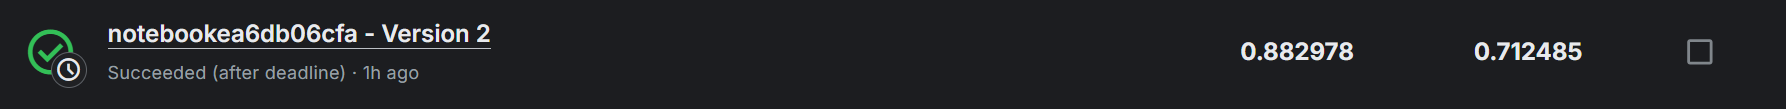

In [ ]:
import os
ckpt_dir = '/content/drive/MyDrive/aptos_checkpoints'
for f in os.listdir(ckpt_dir):
    print(f, '→', round(os.path.getsize(os.path.join(ckpt_dir, f))/1e6, 1), 'MB')

best_fold0.pth → 43.4 MB
ckpt_fold0.pth → 129.3 MB
best_fold1.pth → 43.4 MB
ckpt_fold1.pth → 129.3 MB
best_fold2.pth → 43.4 MB
ckpt_fold2.pth → 129.3 MB
best_fold3.pth → 43.4 MB
ckpt_fold3.pth → 129.3 MB
best_fold4.pth → 43.4 MB
ckpt_fold4.pth → 129.3 MB


# 5-fold 앙상블

In [ ]:
CFG.train_folds = [4]
CFG.resume = True
run_training()

Device: cuda
Model: efficientnet_b3, Image Size: 300
Epochs: 25, Batch Size: 16
Loss: CORAL Ordinal Regression

전체 데이터: 3662건
클래스 분포:
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64


FOLD 4
  Train: 2930, Valid: 732


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

  ✅ 체크포인트 복원! Epoch 17부터 이어서 학습
     (현재 Best Kappa: 0.8950, Epoch 16)

  Epoch 18/25 (lr: 2.40e-05)


Valid: 100%|██████████| 23/23 [02:07<00:00,  5.56s/it]


  Train Loss: 0.1568, Kappa: 0.9395
  Valid Loss: 0.3721, Kappa: 0.8838
  Pred dist: [360  97 156  83  36], True dist: [361  74 199  39  59]
  💾 체크포인트 저장 (Epoch 18)

  Epoch 19/25 (lr: 1.89e-05)


...

  Train Loss: 0.1455, Kappa: 0.9383
  Valid Loss: 0.3898, Kappa: 0.8932
  Pred dist: [358  83 184  73  34], True dist: [361  74 199  39  59]
  💾 체크포인트 저장 (Epoch 23)

  Epoch 24/25 (lr: 2.56e-06)


Valid: 100%|██████████| 23/23 [02:03<00:00,  5.39s/it]


  Train Loss: 0.1453, Kappa: 0.9448
  Valid Loss: 0.3895, Kappa: 0.8922
  Pred dist: [359  82 182  75  34], True dist: [361  74 199  39  59]
  💾 체크포인트 저장 (Epoch 24)

  Epoch 25/25 (lr: 1.39e-06)


Valid: 100%|██████████| 23/23 [02:05<00:00,  5.46s/it]


  Train Loss: 0.1471, Kappa: 0.9469
  Valid Loss: 0.4051, Kappa: 0.8844
  Pred dist: [359  99 168  76  30], True dist: [361  74 199  39  59]
  💾 체크포인트 저장 (Epoch 25)

  Fold 4 완료 — Best Kappa: 0.8950 (Epoch 16)

전체 결과: ['0.8950']
평균 Kappa: 0.8950


## 5-fold 앙상블 중간과정 - (0, 1, 2) 실행 결과

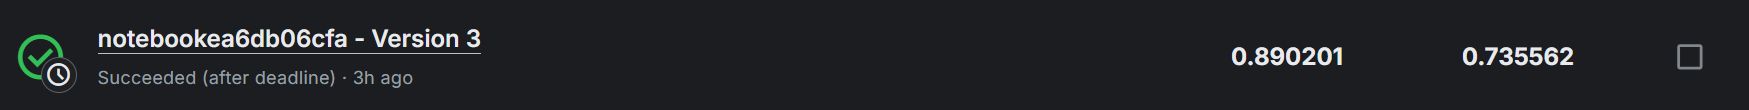

## 5-fold 앙상블 중간과정 - (0, 1, 2, 3) 실행 결과

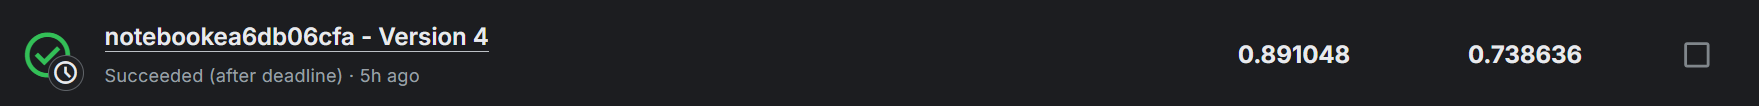

## 5-fold 앙상블 중간과정 - (0, 1, 2, 3, 4) 실행 결과

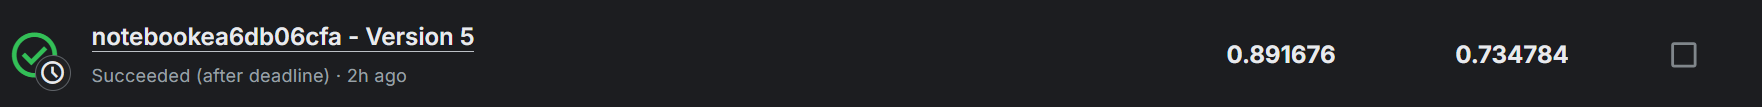